In [14]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append(os.path.dirname("../"))
from statistical_helpers_per_model import run_demsar_framework_by_family, plot_cd_diagram

In [15]:
csv_path = "spearman_inference_fix.csv"
gcn_mlp_results_df = pd.read_csv(csv_path)
metric_to_use = "mae"
gcn_mlp_results_df.head()

,product_id,store_id,seed,metric,model_variant,window_size,step_size,threshold,percentile,enable_edges,enable_second_degree,ablate_z,node_feature_mode,rmse,mae,bias,r2_score,pocid
0,278,6269,42,spearman,lstm_baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.066752,9.085234,-5.280605,10.624836,0.572368
1,278,6269,42,spearman,mlp_baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.900153,8.012110,-1.727077,7.884873,0.605263
2,278,6269,42,spearman,graph2vec_lstm,30.0,1.0,0.634,NaN,True,False,False,catch24_minmaxlast,12.222276,8.310751,-2.305558,8.765215,0.618421
3,278,6269,42,spearman,graph2vec_mlp,30.0,1.0,0.634,NaN,True,False,False,catch24_minmaxlast,11.761272,8.306817,-1.432327,8.315422,0.598684
4,278,6269,42,spearman,gcn_lstm,30.0,1.0,0.634,NaN,True,False,False,catch24_minmaxlast,12.418634,8.192781,-3.055431,9.021370,0.611842


[*] MODEL FAMILY: 'lstm' -> ['lstm_baseline', 'graph2vec_lstm', 'gcn_lstm', 'gat_lstm']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for MAE | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
lstm_baseline             : 2.180
graph2vec_lstm            : 2.265
gcn_lstm                  : 2.727
gat_lstm                  : 2.828


--- Friedman Test Results ---
Test Statistic: 114.0500
P-value:        1.4744e-24

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
                gat_lstm  gcn_lstm  graph2vec_lstm  lstm_baseline
gat_lstm          1.0000    0.5221          0.0000         0.0000
gcn_lstm          0.5221    1.0000          0.0000         0.0000
graph2vec_lstm    0.0000    0.0000          1.0000         0.6645
lstm_baseline     0.0000    0

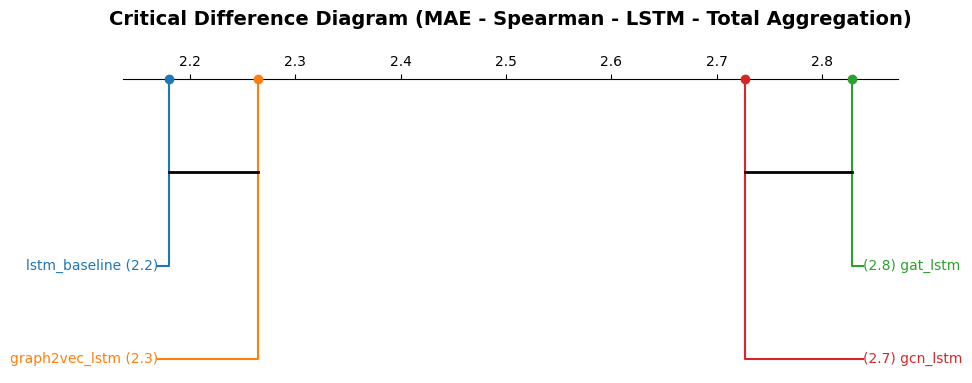

[*] MODEL FAMILY: 'lstm' -> ['lstm_baseline', 'graph2vec_lstm', 'gcn_lstm', 'gat_lstm']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for POCID | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
gat_lstm                  : 2.112
gcn_lstm                  : 2.343
graph2vec_lstm            : 2.637
lstm_baseline             : 2.908


--- Friedman Test Results ---
Test Statistic: 135.4500
P-value:        3.6174e-29

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
                gat_lstm  gcn_lstm  graph2vec_lstm  lstm_baseline
gat_lstm          1.0000    0.0102          0.0000         0.0000
gcn_lstm          0.0102    1.0000          0.0005         0.0000
graph2vec_lstm    0.0000    0.0005          1.0000         0.0015
lstm_baseline     0.0000   

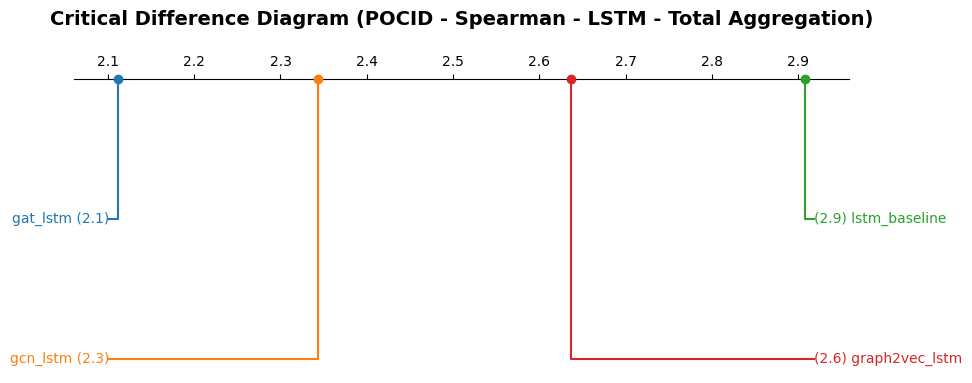

[*] MODEL FAMILY: 'mlp' -> ['mlp_baseline', 'graph2vec_mlp', 'gcn_mlp', 'gat_mlp']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for MAE | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
mlp_baseline              : 2.178
graph2vec_mlp             : 2.253
gcn_mlp                   : 2.757
gat_mlp                   : 2.812


--- Friedman Test Results ---
Test Statistic: 117.8380
P-value:        2.2544e-25

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
               gat_mlp  gcn_mlp  graph2vec_mlp  mlp_baseline
gat_mlp         1.0000   0.8818         0.0000        0.0000
gcn_mlp         0.8818   1.0000         0.0000        0.0000
graph2vec_mlp   0.0000   0.0000         1.0000        0.7458
mlp_baseline    0.0000   0.0000         0.7458        

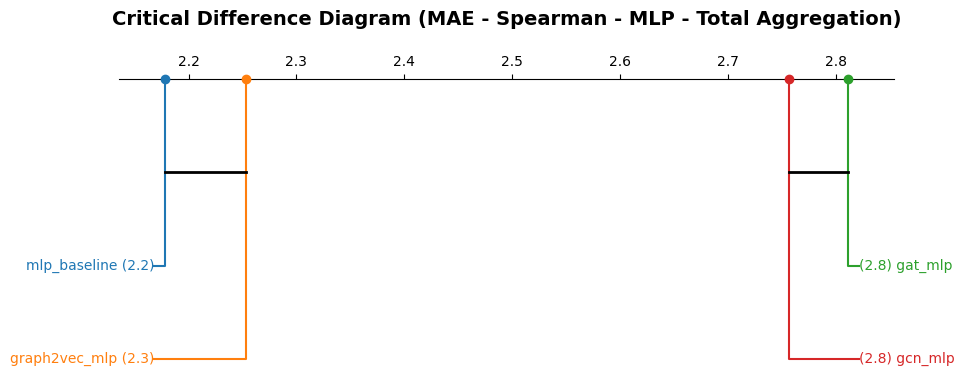

[*] MODEL FAMILY: 'mlp' -> ['mlp_baseline', 'graph2vec_mlp', 'gcn_mlp', 'gat_mlp']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for POCID | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
gat_mlp                   : 2.343
gcn_mlp                   : 2.357
graph2vec_mlp             : 2.568
mlp_baseline              : 2.731


--- Friedman Test Results ---
Test Statistic: 38.7331
P-value:        1.9770e-08

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
               gat_mlp  gcn_mlp  graph2vec_mlp  mlp_baseline
gat_mlp         1.0000   0.9976         0.0135        0.0000
gcn_mlp         0.9976   1.0000         0.0242        0.0000
graph2vec_mlp   0.0135   0.0242         1.0000        0.1287
mlp_baseline    0.0000   0.0000         0.1287       

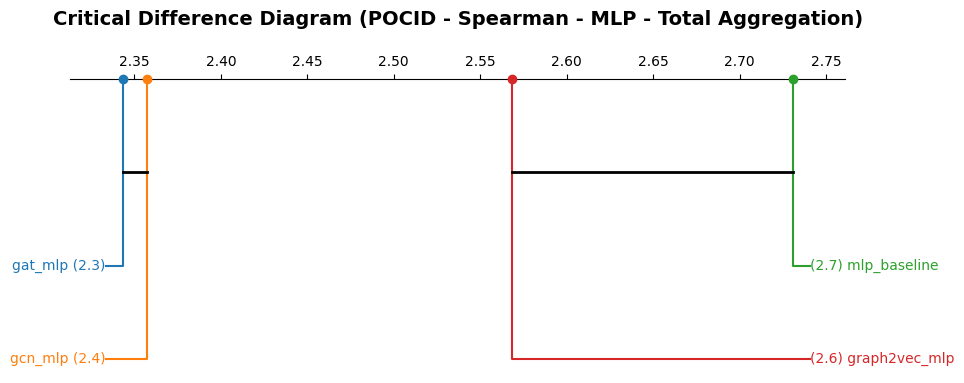

In [16]:
# --- Conservative robustness check: per-product blocks (mean over seeds) ---
# Collapses seeds into one value per product, giving N = n_products independent
# blocks (canonical Demsar). Compare against the mode='total' (product x seed) runs.
for fam in ['lstm', 'mlp']:
    for met in ['mae', 'pocid']:
        pivot, ranks, p_vals = run_demsar_framework_by_family(
            csv_path, metric=met, mode='per_product', model_family=fam)
        plot_cd_diagram(ranks, p_vals, metric=met,
                        mode='per_product', model_family=fam)


[*] MODEL FAMILY: 'lstm' -> ['lstm_baseline', 'graph2vec_lstm', 'gcn_lstm', 'gat_lstm']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for MAE | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
lstm_baseline             : 2.180
graph2vec_lstm            : 2.265
gcn_lstm                  : 2.727
gat_lstm                  : 2.828


--- Friedman Test Results ---
Test Statistic: 114.0500
P-value:        1.4744e-24

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
                gat_lstm  gcn_lstm  graph2vec_lstm  lstm_baseline
gat_lstm          1.0000    0.5221          0.0000         0.0000
gcn_lstm          0.5221    1.0000          0.0000         0.0000
graph2vec_lstm    0.0000    0.0000          1.0000         0.6645
lstm_baseline     0.0000    0

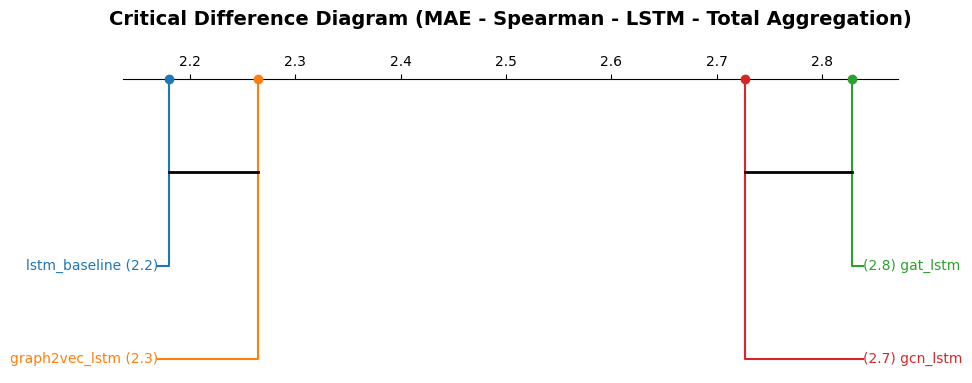

In [17]:
pivot, ranks, p_vals = run_demsar_framework_by_family(csv_path, metric=metric_to_use, mode='total', model_family='lstm')
plot_cd_diagram(ranks, p_vals, metric=metric_to_use, mode='total', model_family='lstm')

[*] MODEL FAMILY: 'mlp' -> ['mlp_baseline', 'graph2vec_mlp', 'gcn_mlp', 'gat_mlp']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for MAE | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
mlp_baseline              : 2.178
graph2vec_mlp             : 2.253
gcn_mlp                   : 2.757
gat_mlp                   : 2.812


--- Friedman Test Results ---
Test Statistic: 117.8380
P-value:        2.2544e-25

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
               gat_mlp  gcn_mlp  graph2vec_mlp  mlp_baseline
gat_mlp         1.0000   0.8818         0.0000        0.0000
gcn_mlp         0.8818   1.0000         0.0000        0.0000
graph2vec_mlp   0.0000   0.0000         1.0000        0.7458
mlp_baseline    0.0000   0.0000         0.7458        

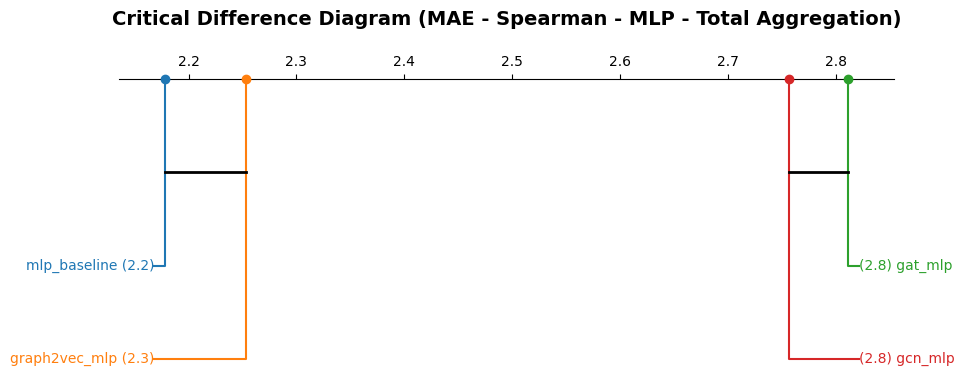

In [18]:
        # MLP family — same call, just swap the family
pivot, ranks, p_vals = run_demsar_framework_by_family(csv_path, metric='mae', mode='total', model_family='mlp')
plot_cd_diagram(ranks, p_vals, metric='mae', mode='total', model_family='mlp')

[*] MODEL FAMILY: 'lstm' -> ['lstm_baseline', 'graph2vec_lstm', 'gcn_lstm', 'gat_lstm']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for POCID | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
gat_lstm                  : 2.112
gcn_lstm                  : 2.343
graph2vec_lstm            : 2.637
lstm_baseline             : 2.908


--- Friedman Test Results ---
Test Statistic: 135.4500
P-value:        3.6174e-29

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
                gat_lstm  gcn_lstm  graph2vec_lstm  lstm_baseline
gat_lstm          1.0000    0.0102          0.0000         0.0000
gcn_lstm          0.0102    1.0000          0.0005         0.0000
graph2vec_lstm    0.0000    0.0005          1.0000         0.0015
lstm_baseline     0.0000   

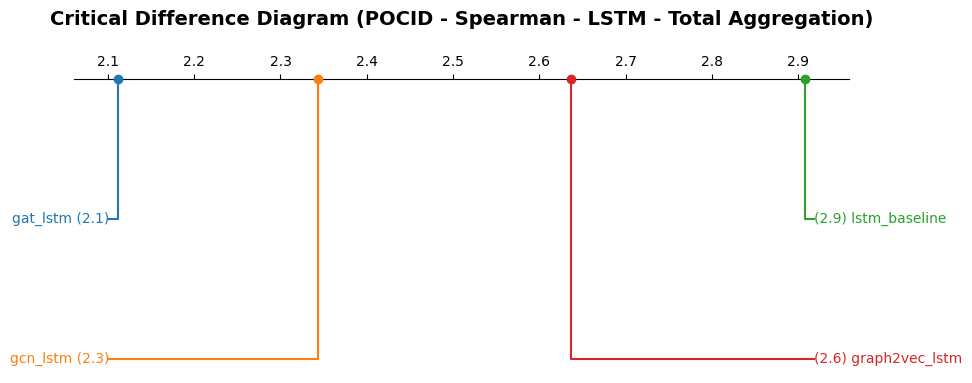

In [19]:
metric_to_use = "pocid"
pivot, ranks, p_vals = run_demsar_framework_by_family(csv_path, metric=metric_to_use, mode='total', model_family='lstm')
plot_cd_diagram(ranks, p_vals, metric=metric_to_use, mode='total', model_family='lstm')

[*] MODEL FAMILY: 'mlp' -> ['mlp_baseline', 'graph2vec_mlp', 'gcn_mlp', 'gat_mlp']
[*] STANDARD MODE: Filtered out ablate_z=True runs.

--- Running Statistical Evaluation for POCID | TOTAL SEEDS ---
Loaded 600 blocks.
Retained 600 complete blocks after dropping missing runs.

--- Average Ranks (Lower is Better) ---
gat_mlp                   : 2.343
gcn_mlp                   : 2.357
graph2vec_mlp             : 2.568
mlp_baseline              : 2.731


--- Friedman Test Results ---
Test Statistic: 38.7331
P-value:        1.9770e-08

Result: Reject the null hypothesis (p < 0.05).
There is a statistically significant difference between the models.

--- Post-Hoc Nemenyi Test (Pairwise p-values) ---
               gat_mlp  gcn_mlp  graph2vec_mlp  mlp_baseline
gat_mlp         1.0000   0.9976         0.0135        0.0000
gcn_mlp         0.9976   1.0000         0.0242        0.0000
graph2vec_mlp   0.0135   0.0242         1.0000        0.1287
mlp_baseline    0.0000   0.0000         0.1287       

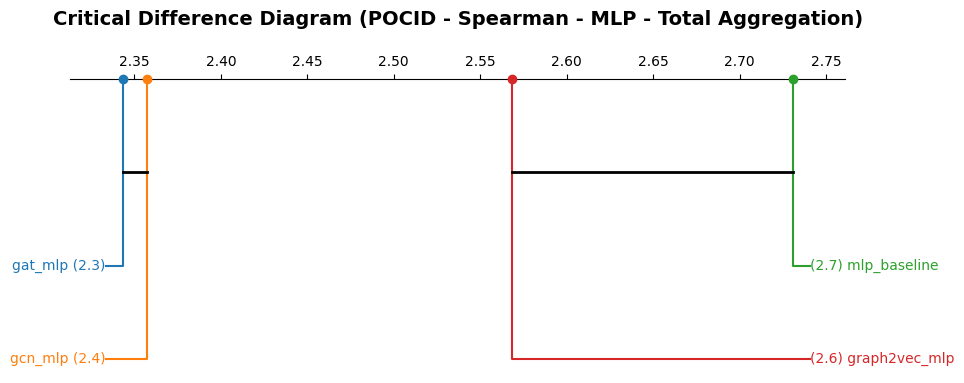

In [20]:
pivot, ranks, p_vals = run_demsar_framework_by_family(csv_path, metric=metric_to_use, mode='total', model_family='mlp')
plot_cd_diagram(ranks, p_vals, metric=metric_to_use, mode='total', model_family='mlp')